> **Chapter 13, Part 5** | Continues from [13.4 Visibility Graphs of Governance Time Series](13.4%20Visibility%20Graphs%20of%20Governance%20Time%20Series.ipynb). **Focus:** AI is both a governance subject and an agent. Build a provenance graph, then build a parser.

# AI as Governance Subject and Agent

AI sits in two governance positions simultaneously.

- **As a subject.** An AI system has a provenance graph: data sources, preprocessing, training run, evaluations, deployment, monitoring. Each node introduces governance obligations. The blast radius of a defect propagates through the same graph. The structural lens from Chapter 12.5 (lineage and fault propagation) applies directly.
- **As an agent.** An AI system can read text and produce structured output. A free-text governance incident report can be parsed by an LLM into a `GovernanceIncident` object, which feeds the apparatus from notebooks 13.1 through 13.4. This makes AI a measurement instrument for governance research, not just a subject of it.

This notebook builds both. The subject side uses NetworkX and the box-covering algorithm to compute the AI provenance graph and identify high-blast-radius nodes. The agent side wires the Anthropic Claude API into a `LLMParser`, with a deterministic `MockParser` that fires when no API key is present so the notebook executes in any environment.

## The honesty up front

AI mediation is not free. The parser can hallucinate. Pressure scores produced by a parser are not equivalent to validated psychometric instruments. The notebook 13.8 closer names these failure modes; this notebook builds the apparatus carefully enough that the failure modes are addressable rather than fatal.


In [1]:
import os
import json
import re
from dataclasses import dataclass, field
from typing import List, Optional
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


# ----------------------------- Subject side: AI provenance graph -----------------------------

PROV_NODES = [
    ('webcrawl_2025', 'data_source'),
    ('books_corpus', 'data_source'),
    ('code_corpus', 'data_source'),
    ('synthetic_examples', 'data_source'),
    ('dedupe', 'preprocessing'),
    ('tokenize', 'preprocessing'),
    ('safety_filter', 'preprocessing'),
    ('train_run_v1', 'training'),
    ('eval_holdout', 'evaluation'),
    ('eval_red_team', 'evaluation'),
    ('eval_fairness', 'evaluation'),
    ('release_v1', 'deployment'),
    ('production_v1', 'deployment'),
    ('monitor_drift', 'monitoring'),
    ('monitor_safety', 'monitoring'),
    ('monitor_usage', 'monitoring'),
]
PROV_EDGES = [
    ('webcrawl_2025', 'dedupe'),
    ('books_corpus', 'dedupe'),
    ('code_corpus', 'dedupe'),
    ('synthetic_examples', 'dedupe'),
    ('dedupe', 'tokenize'),
    ('tokenize', 'safety_filter'),
    ('safety_filter', 'train_run_v1'),
    ('train_run_v1', 'eval_holdout'),
    ('train_run_v1', 'eval_red_team'),
    ('train_run_v1', 'eval_fairness'),
    ('eval_holdout', 'release_v1'),
    ('eval_red_team', 'release_v1'),
    ('eval_fairness', 'release_v1'),
    ('release_v1', 'production_v1'),
    ('production_v1', 'monitor_drift'),
    ('production_v1', 'monitor_safety'),
    ('production_v1', 'monitor_usage'),
]

P = nx.DiGraph()
for n, kind in PROV_NODES:
    P.add_node(n, kind=kind)
P.add_edges_from(PROV_EDGES)
print(f'Provenance graph: {P.number_of_nodes()} nodes, {P.number_of_edges()} edges')


Provenance graph: 16 nodes, 17 edges


In [2]:
def blast_radius(G: nx.DiGraph, node: str) -> set:
    if node not in G:
        return set()
    return nx.descendants(G, node) | {node}


reach = {n: len(blast_radius(P, n)) for n in P.nodes()}
ranked = sorted(reach.items(), key=lambda x: x[1], reverse=True)
print('Blast-radius ranking (number of downstream nodes affected if this stage fails):')
for n, r in ranked[:10]:
    kind = P.nodes[n]['kind']
    print(f'  {n:>22s} ({kind:>13s}): {r}')


Blast-radius ranking (number of downstream nodes affected if this stage fails):
           webcrawl_2025 (  data_source): 13
            books_corpus (  data_source): 13
             code_corpus (  data_source): 13
      synthetic_examples (  data_source): 13
                  dedupe (preprocessing): 12
                tokenize (preprocessing): 11
           safety_filter (preprocessing): 10
            train_run_v1 (     training): 9
            eval_holdout (   evaluation): 6
           eval_red_team (   evaluation): 6


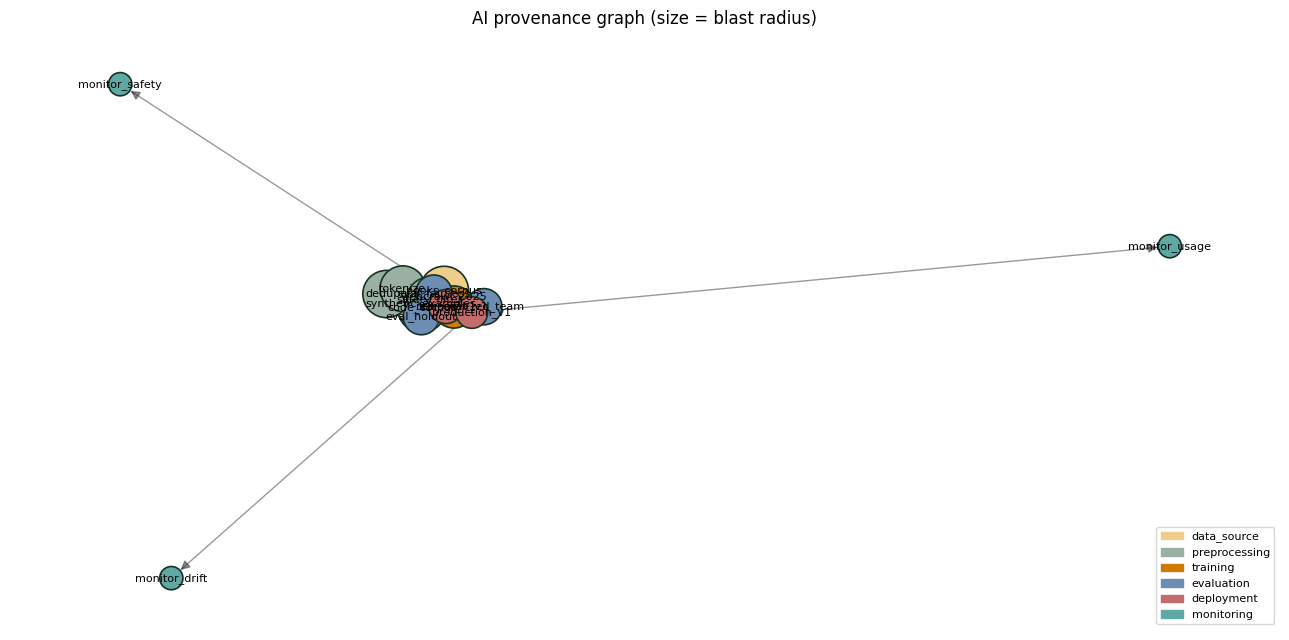

Top blast-radius nodes are the ones to govern hardest. Source data nodes
(data_source) sit at the root and reach the most descendants; safety_filter
and tokenize sit on the critical path. Training and release are pivotal.


In [3]:
# Render the provenance graph with blast-radius colour coding.
KIND_COLOUR = {
    'data_source': '#efce8a',
    'preprocessing': '#9ab0a3',
    'training': '#d17a00',
    'evaluation': '#6e8db4',
    'deployment': '#c46b6b',
    'monitoring': '#5fa8a3',
}

pos = nx.spring_layout(P, seed=3, iterations=200)
fig, ax = plt.subplots(figsize=(13, 6.5))
node_sizes = [200 + 80 * reach[n] for n in P.nodes()]
node_colors = [KIND_COLOUR[P.nodes[n]['kind']] for n in P.nodes()]
nx.draw_networkx_edges(P, pos, alpha=0.4, arrows=True, arrowsize=14, ax=ax)
nx.draw_networkx_nodes(P, pos, node_size=node_sizes, node_color=node_colors,
                       edgecolors='#173326', linewidths=1.2, ax=ax)
nx.draw_networkx_labels(P, pos, font_size=8, ax=ax)
ax.set_title('AI provenance graph (size = blast radius)')
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=c, label=k) for k, c in KIND_COLOUR.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

print('Top blast-radius nodes are the ones to govern hardest. Source data nodes')
print('(data_source) sit at the root and reach the most descendants; safety_filter')
print('and tokenize sit on the critical path. Training and release are pivotal.')


## The agent side: building the parser

The parser takes a free-text governance incident report and returns a structured `GovernanceIncident` object. The chain is intentionally minimal: a strict prompt, a JSON-validated response, and a deterministic mock fallback.

The mock parser uses keyword heuristics. It will not match the LLM's quality on edge cases, but it will run anywhere, deterministically, and it serves as the smoke-test surface that all subsequent notebooks rely on.


In [4]:
@dataclass
class GovernanceIncident:
    summary: str
    scales: List[str] = field(default_factory=list)
    dominant_pressure: str = 'unknown'
    suggested_control: str = ''
    confidence: float = 0.0
    citations: List[str] = field(default_factory=list)


SCALE_KEYWORDS = {
    'field': ['regulator', 'legislation', 'statute', 'directive', 'industry-wide', 'across the field', 'eu ', 'sec ', 'occ ', 'sox', 'dora'],
    'firm': ['firm', 'company', 'organization', 'enterprise', 'corporate', 'global policy', 'firm-wide'],
    'division': ['division', 'business unit', 'practice', 'sector', 'vertical'],
    'team': ['team', 'project', 'engagement', 'pod', 'squad'],
    'practitioner': ['individual', 'practitioner', 'analyst', 'engineer', 'consultant', 'me ', 'i ', 'personally'],
}

PRESSURE_KEYWORDS = {
    'coercive': ['regulation', 'audit', 'fine', 'penalty', 'mandate', 'must', 'required', 'compliance', 'contract', 'msa', 'sla', 'enforcement'],
    'mimetic': ['benchmark', 'peer', 'competitor', 'industry standard', 'best practice', 'similar firms', 'leaders adopt'],
    'normative': ['certification', 'training', 'professional', 'ethics', 'code of conduct', 'cdmp', 'standard', 'norm', 'expectation'],
}


class MockParser:
    """Deterministic regex/keyword parser. Always returns a GovernanceIncident."""
    def parse(self, text: str) -> GovernanceIncident:
        t = text.lower()
        scales = [s for s, kws in SCALE_KEYWORDS.items() if any(k in t for k in kws)]
        scores = {p: sum(1 for k in kws if k in t) for p, kws in PRESSURE_KEYWORDS.items()}
        dominant = max(scores, key=scores.get) if any(scores.values()) else 'unknown'
        # Suggested controls keyed by dominant pressure.
        controls = {
            'coercive': 'Add a documented control mapped to the cited regulation; assign owner; record evidence.',
            'mimetic': 'Run a peer benchmark; codify the chosen practice as a firm-wide standard.',
            'normative': 'Update training and certification expectations; align with professional code.',
            'unknown': 'Restate the incident with explicit pressure attribution before proceeding.',
        }
        return GovernanceIncident(
            summary=text.strip()[:240],
            scales=scales,
            dominant_pressure=dominant,
            suggested_control=controls[dominant],
            confidence=0.4 + 0.1 * sum(1 for v in scores.values() if v > 0),
            citations=['Mock parser; replace with LLMParser for higher-fidelity inference'],
        )


# Smoke test with a sample report.
SAMPLE_REPORT = (
    'Last quarter our model risk team was flagged in an OCC audit because '
    'the firm-wide model inventory did not include three production models that '
    'individual analysts had deployed via a shadow Snowflake account. The audit '
    'cited SOX and OCC guidance. Peer firms have moved to centralized model '
    'registries; we have lagged behind on this.'
)
mock = MockParser()
result_mock = mock.parse(SAMPLE_REPORT)
print('Mock parser output:')
print(json.dumps(result_mock.__dict__, indent=2))


Mock parser output:
{
  "summary": "Last quarter our model risk team was flagged in an OCC audit because the firm-wide model inventory did not include three production models that individual analysts had deployed via a shadow Snowflake account. The audit cited SOX and OCC gui",
  "scales": [
    "field",
    "firm",
    "team",
    "practitioner"
  ],
  "dominant_pressure": "coercive",
  "suggested_control": "Add a documented control mapped to the cited regulation; assign owner; record evidence.",
  "confidence": 0.6000000000000001,
  "citations": [
    "Mock parser; replace with LLMParser for higher-fidelity inference"
  ]
}


In [5]:
class LLMParser:
    """Anthropic-backed parser. Falls back to mock on missing key, network error,
    or malformed response (V004 strict JSON validation)."""
    def __init__(self):
        self.api_key = os.environ.get('ANTHROPIC_API_KEY')
        self.fallback = MockParser()
        self._client = None
        if self.api_key:
            try:
                import anthropic
                self._client = anthropic.Anthropic(api_key=self.api_key)
            except Exception as e:
                print(f'Could not initialize Anthropic client ({type(e).__name__}: {e}); falling back to mock.')

    @property
    def is_live(self) -> bool:
        return self._client is not None

    def parse(self, text: str) -> GovernanceIncident:
        if not self.is_live:
            return self.fallback.parse(text)
        sys = (
            'You are a data governance researcher. Return a strict JSON object with keys '
            '"summary" (string, <= 240 chars), "scales" (list of strings drawn only from '
            '["field","firm","division","team","practitioner"]), "dominant_pressure" '
            '(one of "coercive","mimetic","normative","unknown"), "suggested_control" '
            '(string), "confidence" (number in [0,1]), "citations" (list of strings). '
            'Do not include any prose outside the JSON.'
        )
        try:
            response = self._client.messages.create(
                model='claude-3-haiku-20240307',
                max_tokens=600,
                system=sys,
                messages=[{'role': 'user', 'content': text}],
            )
            payload = response.content[0].text
            match = re.search(r'\{.*\}', payload, re.DOTALL)
            if not match:
                return self.fallback.parse(text)
            data = json.loads(match.group(0))
            return GovernanceIncident(
                summary=str(data.get('summary', text[:240])),
                scales=list(data.get('scales', [])),
                dominant_pressure=str(data.get('dominant_pressure', 'unknown')),
                suggested_control=str(data.get('suggested_control', '')),
                confidence=float(data.get('confidence', 0.5)),
                citations=list(data.get('citations', [])),
            )
        except Exception as e:
            print(f'LLMParser failed ({type(e).__name__}: {e}); falling back to mock.')
            return self.fallback.parse(text)


# Try the live parser; will fall back to mock if no key is set.
parser = LLMParser()
print(f'Parser is_live: {parser.is_live}')
result_live = parser.parse(SAMPLE_REPORT)
print('Active parser output:')
print(json.dumps(result_live.__dict__, indent=2))


Parser is_live: False
Active parser output:
{
  "summary": "Last quarter our model risk team was flagged in an OCC audit because the firm-wide model inventory did not include three production models that individual analysts had deployed via a shadow Snowflake account. The audit cited SOX and OCC gui",
  "scales": [
    "field",
    "firm",
    "team",
    "practitioner"
  ],
  "dominant_pressure": "coercive",
  "suggested_control": "Add a documented control mapped to the cited regulation; assign owner; record evidence.",
  "confidence": 0.6000000000000001,
  "citations": [
    "Mock parser; replace with LLMParser for higher-fidelity inference"
  ]
}


## Reading the parser output

When the Anthropic key is present, the parser produces structured pressure attributions in seconds. When the key is absent, the mock parser produces a similar shape using deterministic heuristics. The chapter executes in either configuration.

The output shape is the integration point. Every later notebook in this chapter consumes `GovernanceIncident` objects. The user can swap the parser implementation (LLM, fine-tuned classifier, hand-coded rules) without changing downstream code. This is the same pattern Chapter 8's "Ask Warren" chatbot uses: a clean boundary between the LLM call and the consuming code keeps the LLM substitutable.

## Failure modes named explicitly

- **R001 hallucination.** The LLM may invent regulations, cite plausible-sounding statutes that do not exist, or produce a `dominant_pressure` value that is not in the allowed enum. The strict JSON validation catches structural errors but cannot catch invented citations. Trust the parser for triage; verify before public attribution.
- **R001 prompt sensitivity.** Reasonable prompt variations produce different pressure attributions. A research-grade pipeline would average across prompt variants and report variance. The teaching pipeline does not.
- **R001 small-N validation.** No human-coder agreement was computed for this parser. The H3 hypothesis in the research plan is exactly this: validate the AI-mediated pressure profile against trained human qualitative coders.

## Practical implications

- **For practitioners:** the parser is faster than a hand-coded analysis and useful for triage. Do not use parser output as evidence in a regulatory submission without human review.
- **For researchers:** the parser is a candidate measurement instrument that requires validation before becoming a research tool. The validation study is described in the research plan.
- **For students:** the API call wrapper, JSON validation, and mock fallback are the engineering pattern. The same scaffold supports any structured-output LLM use case.
